In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
import numpy as np
import os
import re
import warnings
from numba.core.errors import NumbaDeprecationWarning
import urllib.request
from pathlib import Path
import celltypist
from celltypist import models
from scipy.sparse import csr_matrix
import harmonypy as hm

/rds/general/user/ztb25/home/miniforge3/envs/m10/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
In order to use the mouse gastrulation seqFISH datsets, please install squidpy (see https://github.com/scverse/squidpy).
In order to use sagenet models, please install pytorch geometric (see https://pytorch-geometric.readthedocs.io) and 
 captum (see https://github.com/pytorch/captum).
mvTCR is not installed. To use mvTCR models, please install it first using "pip install mvtcr"
multigrate is not installed. To use multigrate models, please install it first using "pip install multigrate".


In [2]:
sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

In [3]:
# import preprocessed dataset

dir = "/rds/general/user/ztb25/home/PBMC_datasets/6/PBMC6_preprocessed.h5ad"

adata = sc.read(dir)

In [4]:
# save raw counts first
adata.layers["counts"] = adata.X.copy()

# then set normalised as active layer for PCA
adata.X = adata.layers["log1p_norm"]

In [5]:
# compute PCA
sc.pp.pca(
    adata, svd_solver="arpack", use_highly_variable=True)

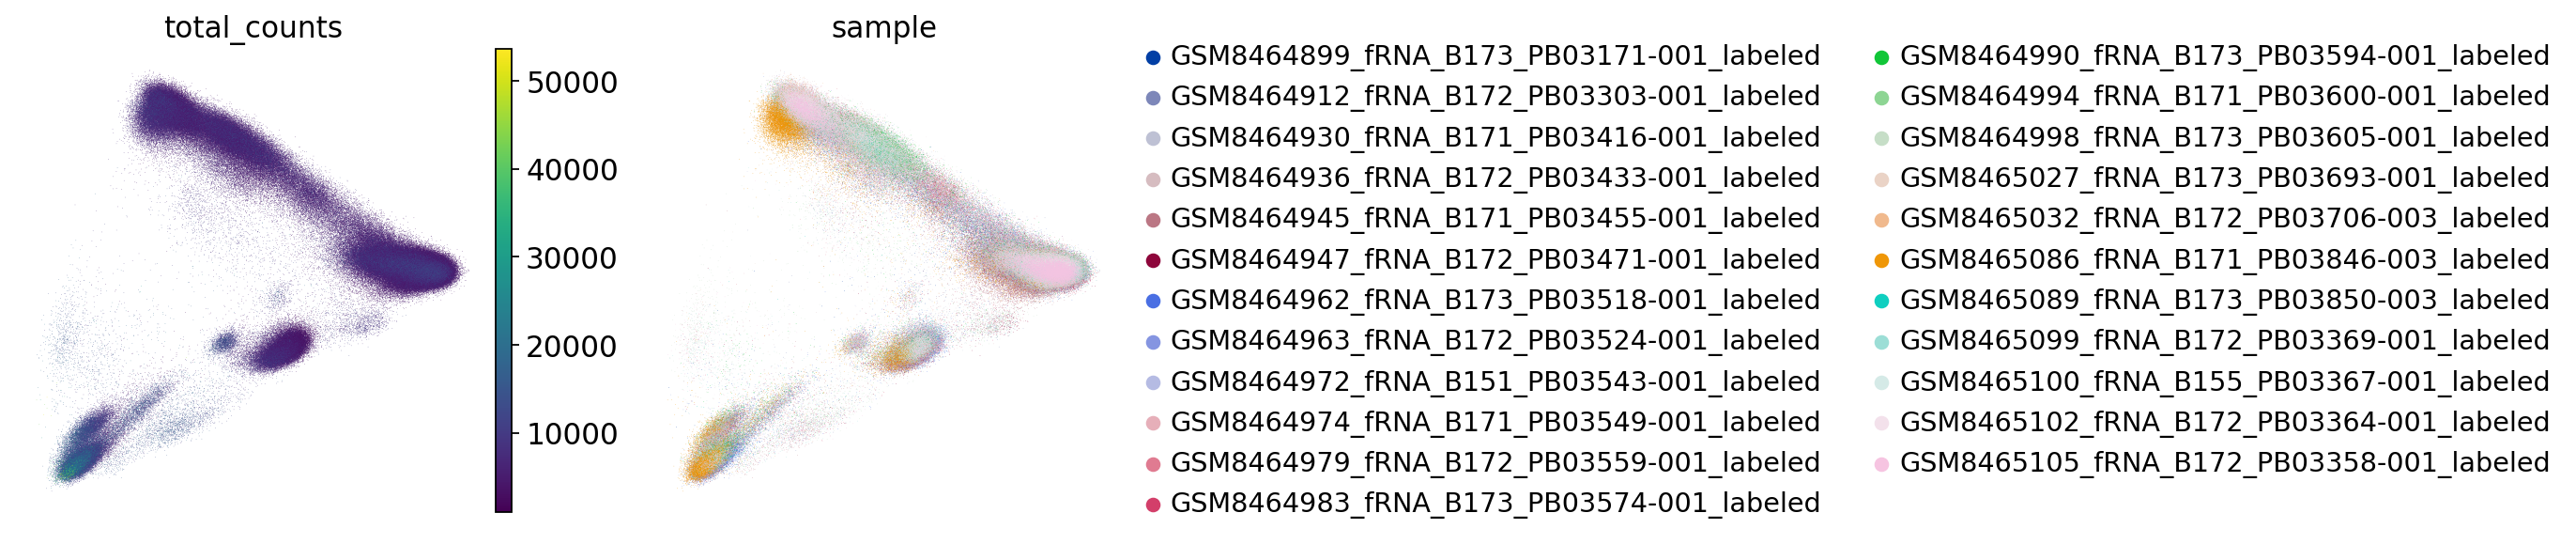

In [6]:
# plot PCA
sc.pl.pca_scatter(adata, color= ["total_counts", "sample"])
# color by total counts, sample and batch to preliminarily check for batch effects

In [8]:
adata.obs

,sample,GSM_id,SF_id,age,gender,race,age_bin,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,outlier,mt_outlier,n_genes,doublet_score,predicted_doublet
4af7cd12bb7811ee9b58de0137763e50-0,GSM8464899_fRNA_B173_PB03171-001_labeled,GSM8464899,SF4033,84.0,Male,Caucasian,80+,3634,8.198364,8380,9.033723,10.978520,36,3.610918,0.429594,False,False,3634,0.010486,False
4af7cfd8bb7811ee9b58de0137763e50-0,GSM8464899_fRNA_B173_PB03171-001_labeled,GSM8464899,SF4033,84.0,Male,Caucasian,80+,2629,7.874739,4698,8.455105,7.556407,49,3.912023,1.042997,False,False,2629,0.006771,False
4af7d122bb7811ee9b58de0137763e50-0,GSM8464899_fRNA_B173_PB03171-001_labeled,GSM8464899,SF4033,84.0,Male,Caucasian,80+,3966,8.285765,10406,9.250234,11.041707,27,3.332205,0.259466,False,False,3966,0.028409,False
4af7d230bb7811ee9b58de0137763e50-0,GSM8464899_fRNA_B173_PB03171-001_labeled,GSM8464899,SF4033,84.0,Male,Caucasian,80+,4238,8.352083,11175,9.321524,13.601790,149,5.010635,1.333333,False,False,4237,0.031191,False
4af7d3fcbb7811ee9b58de0137763e50-0,GSM8464899_fRNA_B173_PB03171-001_labeled,GSM8464899,SF4033,84.0,Male,Caucasian,80+,3044,8.021256,5705,8.649274,7.572305,63,4.158883,1.104294,False,False,3044,0.012264,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6ae7a1d0b13a11ee8474b629c0feacc1-22,GSM8465105_fRNA_B172_PB03358-001_labeled,GSM8465105,SF4612,73.0,Male,Caucasian,70-79,4731,8.462103,11105,9.315241,6.726700,98,4.595120,0.882485,False,False,4723,0.080233,False
6ae7a23eb13a11ee8474b629c0feacc1-22,GSM8465105_fRNA_B172_PB03358-001_labeled,GSM8465105,SF4612,73.0,Male,Caucasian,70-79,2748,7.918992,4929,8.503094,6.877663,90,4.510860,1.825928,False,False,2748,0.052527,False
6ae7a2b6b13a11ee8474b629c0feacc1-22,GSM8465105_fRNA_B172_PB03358-001_labeled,GSM8465105,SF4612,73.0,Male,Caucasian,70-79,2730,7.912423,5005,8.518392,8.671329,140,4.948760,2.797203,False,False,2730,0.022993,False
6ae7a3a6b13a11ee8474b629c0feacc1-22,GSM8465105_fRNA_B172_PB03358-001_labeled,GSM8465105,SF4612,73.0,Male,Caucasian,70-79,2981,8.000349,5611,8.632662,7.200143,106,4.672829,1.889146,False,False,2981,0.019071,False


In [9]:
# build neighbour graph (used for leiden clustering and UMAP) using the first 30 principal components (stick with this defualt?)
sc.pp.neighbors(adata, n_pcs=30)

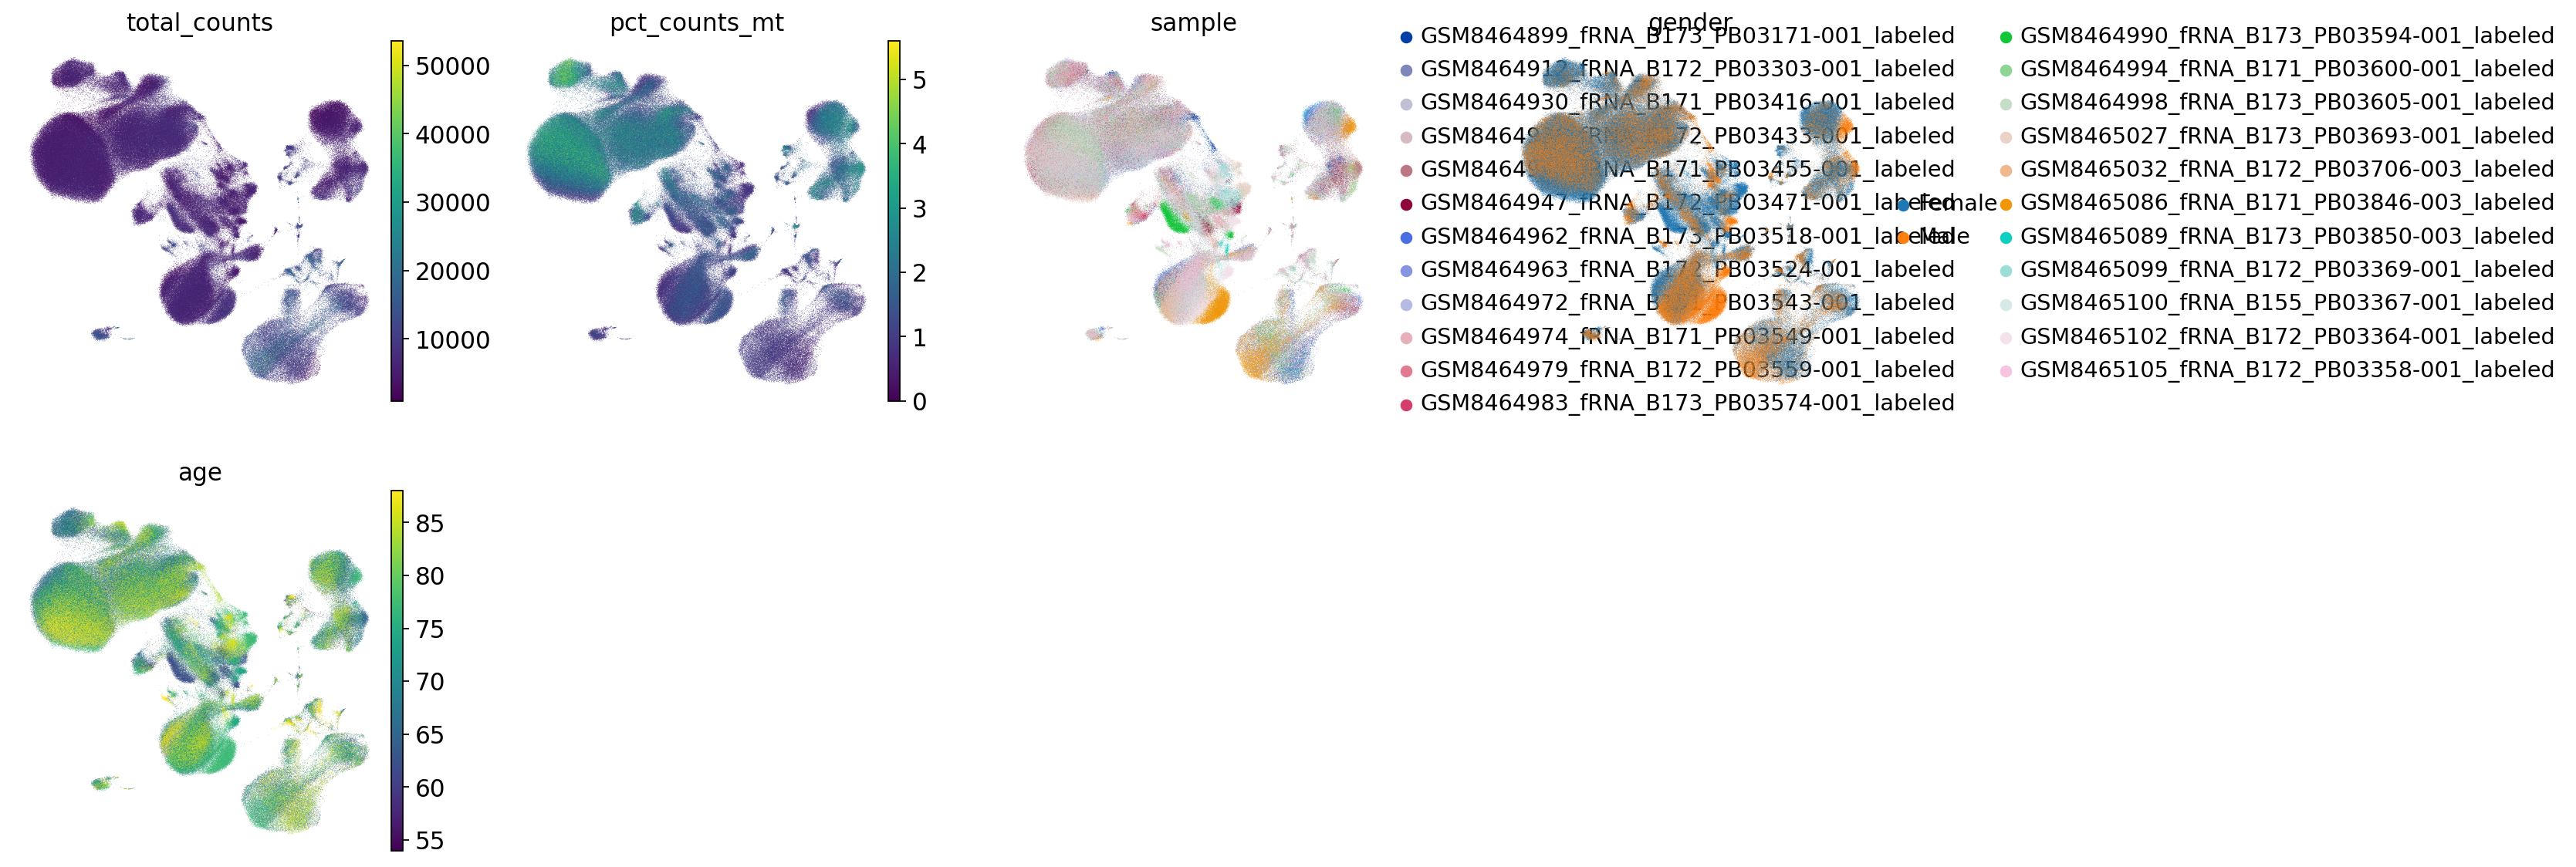

In [ ]:
# compute UMAP
sc.tl.umap(adata)

# plot UMAP to check quality control metrics, i.e. see if cells are clustering by non-biological factors
sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", "sample", "gender", "age", "batch", "race"],
    legend_loc=None
)

# batch correction needed

In [ ]:
# batch correction (harmony)


ho = hm.run_harmony(adata.obsm["X_pca"], adata.obs, "batch")
# adata.obsm["X_pca_harmony"] = ho.Z_corr.T
adata.obsm["X_pca_harmony"] = ho.Z_corr


print(adata.obsm["X_pca_harmony"].shape)


In [ ]:
# recompute UMAP and neighbours using corrected data

sc.pp.neighbors(adata, use_rep="X_pca_harmony")
sc.tl.umap(adata) # writes to X_umap (default overwritten)

# replot to check for overcorrection

sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", "sample", "gender", "age", "batch", "race"],
    legend_loc=None
)

In [ ]:
# CellTypist

# first prepare data to format needed for cellTypist (normalised to 10,000 counts per cell then log1p transformed)

adata_celltypist = adata.copy()  # make a copy of our adata
adata_celltypist.X = adata.layers["counts"]  # set adata.X to raw counts
sc.pp.normalize_total(
    adata_celltypist, target_sum=10**4
)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata_celltypist)  # log-transform
# make .X dense instead of sparse, for compatibility with celltypist:
adata_celltypist.X = adata_celltypist.X.toarray()

: 

: 

: 

In [ ]:
# download celltypist models for immune cells 
models.download_models(
    force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"]
)

model_low = models.Model.load(model="Immune_All_Low.pkl") # finer annotation level
model_high = models.Model.load(model="Immune_All_High.pkl") # coarser annotation level

In [ ]:
# run high model 

predictions_high = celltypist.annotate(
    adata_celltypist, model=model_high, majority_voting=True #?
)

predictions_high_adata = predictions_high.to_adata() # transform predictions to adata for full output

# copy results into original AnnData obj
adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "conf_score"
]

In [ ]:
# run low model

predictions_low = celltypist.annotate(
    adata_celltypist, model=model_low, majority_voting=True
)

predictions_low_adata = predictions_low.to_adata()

adata.obs["celltypist_cell_label_fine"] = predictions_low_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_fine"] = predictions_low_adata.obs.loc[
    adata.obs.index, "conf_score"
]

In [ ]:
# plot (coarse)

sc.pl.umap(
    adata,
    color=["celltypist_cell_label_coarse", "celltypist_conf_score_coarse"],
    frameon=False,
    sort_order=False,
    wspace=1,
)


In [ ]:
# plot (fine)

sc.pl.umap(
    adata,
    color=["celltypist_cell_label_fine", "celltypist_conf_score_fine"],
    frameon=False,
    sort_order=False,
    wspace=1,
)

In [ ]:
# plot overall relative abundance of each cell type across all samples with 95% CI, and colors corresponding to the cell types in UMAP

# count cells per type per sample, then normalise to %
plot_df = (
    adata.obs.groupby(["sample", "celltypist_cell_label_coarse"])
    .size()
    .reset_index(name="count")
    .assign(rel_abundance=lambda df: df.groupby("sample")["count"].transform(lambda x: x / x.sum() * 100))
)

# derive colors from adata
labels = adata.obs["celltypist_cell_label_coarse"].astype("category").cat.categories
colors = adata.uns["celltypist_cell_label_coarse_colors"]
cell_type_colors_dict = dict(zip(labels, colors))

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="celltypist_cell_label_coarse",  # was "cell_type" — column doesn't exist yet
    y="rel_abundance",
    hue="celltypist_cell_label_coarse",
    palette=cell_type_colors_dict,
    dodge=False,
    legend=False,
    errorbar=("ci", 95),
    capsize=0.1,
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean relative abundance (%)")
plt.xlabel("")
plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 20))
plt.tight_layout()
plt.show()

In [ ]:
# plot paired with reference to check proportions are within normal range

# ---------- Apoil 2017 reference, scaled to % of PBMC ----------
# PBMC denominator: Apoil lymph (2012/µL) + clinical mono ref (500/µL)
# + Autissier DCs (15/µL) ≈ 2527 cells/µL
PBMC_MEAN = 2012 + 500 + 15

# cluster, mean_count, lo_count, hi_count
apoil_rows = [
    ("T cells",                   1473,  700, 2508),
    ("B cells",                    247,   92,  515),
    ("ILC",                        253,   82,  594),
    ("Monocytes",                  500,  200,  800),   # clinical reference, not Apoil
    ("Plasma cells",               3.2,  0.5, 12.4),   # Apoil plasmablasts × B count
    ("DC",                        None, None, None),   # not covered
    ("pDC",                       None, None, None),
    ("Megakaryocytes/platelets",  None, None, None),
]
apoil_ref = pd.DataFrame(
    apoil_rows,
    columns=["celltypist_cell_label_coarse", "mean_count", "lo_count", "hi_count"],
)
apoil_ref["apoil_mean"] = apoil_ref["mean_count"] / PBMC_MEAN * 100
apoil_ref["apoil_lo"]   = apoil_ref["lo_count"]   / PBMC_MEAN * 100
apoil_ref["apoil_hi"]   = apoil_ref["hi_count"]   / PBMC_MEAN * 100
# cap the T-cell upper bound at ~80 so the y axis doesn't break
apoil_ref.loc[apoil_ref["celltypist_cell_label_coarse"] == "T cells", "apoil_hi"] = 80.0

# ---------- aggregate your CTRL: mean + 95% CI per cluster ----------
ctrl_stats = (
    plot_df
    .groupby("celltypist_cell_label_coarse", observed=True)["rel_abundance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
ctrl_stats["ci95"] = 1.96 * ctrl_stats["std"] / np.sqrt(ctrl_stats["count"])

# merge, keeping CTRL order as the x-axis
df = (
    ctrl_stats
    .merge(apoil_ref, on="celltypist_cell_label_coarse", how="left")
    .rename(columns={"mean": "ctrl_mean"})
)

# ---------- paired bar plot ----------
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df))
w = 0.38

# your CTRL (blue) — mean ± 95% CI
ax.bar(
    x - w/2, df["ctrl_mean"], w,
    yerr=df["ci95"], capsize=3.5,
    color="#4f46e5", edgecolor="black", linewidth=0.6,
    label="CTRL (Dataset 1, mean ± 95% CI, scRNA-seq)",
    error_kw=dict(elinewidth=1, ecolor="black"),
)

# Apoil reference (red) — mean with asymmetric 95% RI
err_lo = (df["apoil_mean"] - df["apoil_lo"]).astype(float)
err_hi = (df["apoil_hi"]   - df["apoil_mean"]).astype(float)
ax.bar(
    x + w/2, df["apoil_mean"], w,
    yerr=[err_lo, err_hi], capsize=3.5,
    color="#b91c1c", edgecolor="black", linewidth=0.6,
    label="Apoil 2017 flow reference (n = 253, mean & 95% RI)",
    error_kw=dict(elinewidth=1, ecolor="black"),
)

# mark clusters with no reference
for i, row in df.iterrows():
    if pd.isna(row["apoil_mean"]):
        ax.text(i + w/2, 1.2, "no ref", ha="center", va="bottom",
                rotation=90, color="#b91c1c", fontsize=7.5, style="italic")

# cosmetics
ax.set_xticks(x)
ax.set_xticklabels(df["celltypist_cell_label_coarse"], rotation=30, ha="right")
ax.set_ylabel("Mean relative abundance (% of PBMC)")
ax.set_xlabel("")
ax.set_title("CTRL (Dataset 1) vs Apoil 2017 clinical flow reference")
ax.set_ylim(0, 80)
ax.set_yticks(np.arange(0, 81, 20))
ax.grid(axis="y", linestyle=":", alpha=0.3)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(loc="upper right", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
adata.write("/rds/general/user/ztb25/home/PBMC_datasets/6/PBMC6_clustering.h5ad")